# 00 - Review the Collaborator Data

**Purpose:** turn the source demand and map files into clear tables of substations, transmission routes and power stations for the fixed-capacity interruption workflow.

**Before running:**

- use the repository `.venv` kernel;
- place the expected folders under `data/0-incoming/energy/collaborator`, or set `MU_STAR_DATA_ROOT` to another data folder with the same structure;
- leave source files and filenames unchanged.

**Expected source inputs:**

- `power_demand/Power Demand.xlsx`, containing monthly peak demand and annual demand by customer group;
- `substation/Substation.{shp,shx,dbf,prj}`, containing substation point locations;
- `power_transmission/PowerGrid.{shp,shx,dbf,prj}`, containing transmission route geometry;
- `generation_source/GenSource1.{shp,shx,dbf,prj}`, containing mapped generation point records;
- `generation_source/GenSource2.{shp,shx,dbf,prj}`, containing mapped generation area records;
- optional reference material such as `substation/network_map_2025.png`.

**What this notebook does:** reads the supported source files, writes cleaned tables under `data/1-processed/energy/collaborator`, counts the records found, snaps substations to the transmission routes, maps their coverage and extracts the demand information in the workbook.

**User instructions:** check the map and tables against your knowledge of the Mauritius system. Copy the generated template to `existing_generators.csv`, then add confirmed maximum output, fuel or technology, running cost, status and connected substation for each power station. The notebook does not estimate a station's output from its mapped size or assume that every unnamed polygon is a power station.

**Common adjustments:** you can use a different main data folder, change plot styles or update how clearly labelled source records are grouped. If a new source has different columns or file formats, update the reading code and record where the new data came from.

In [1]:
from importlib import reload
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

import mu_star_energy.intake as intake
import mu_star_energy.paths as project_paths

# Reload local package modules so a long-running notebook kernel does not keep
# paths from before the data folders were renamed.
reload(project_paths)
reload(intake)

REPO_ROOT = project_paths.repo_root()
INPUT_DIR_OVERRIDE = None  # Set to Path(...) only for a one-off source location.
INPUT_DIR = (
    Path(INPUT_DIR_OVERRIDE).expanduser().resolve()
    if INPUT_DIR_OVERRIDE is not None
    else project_paths.incoming_energy_dir() / "collaborator"
)
OUTPUT_DIR = project_paths.processed_energy_dir() / "collaborator"

print("Reading source data from:", INPUT_DIR)
print("Writing cleaned data to:", OUTPUT_DIR)
intake.validate_collaborator_inputs(INPUT_DIR)

prepared = intake.prepare_collaborator_data(INPUT_DIR, OUTPUT_DIR)
prepared

Reading source data from: /Users/carlopalazzi/programming/pypsa_models/pypsa-earth-mauritius-kestrel/data/0-incoming/energy/collaborator
Writing cleaned data to: /Users/carlopalazzi/programming/pypsa_models/pypsa-earth-mauritius-kestrel/data/1-processed/energy/collaborator


PreparedAssets(substations=PosixPath('/Users/carlopalazzi/programming/pypsa_models/pypsa-earth-mauritius-kestrel/data/1-processed/energy/collaborator/substations.parquet'), snapped_substations=PosixPath('/Users/carlopalazzi/programming/pypsa_models/pypsa-earth-mauritius-kestrel/data/1-processed/energy/collaborator/snapped_substations.parquet'), substation_snap_distances=PosixPath('/Users/carlopalazzi/programming/pypsa_models/pypsa-earth-mauritius-kestrel/data/1-processed/energy/collaborator/substation_snap_distances.csv'), transmission_routes=PosixPath('/Users/carlopalazzi/programming/pypsa_models/pypsa-earth-mauritius-kestrel/data/1-processed/energy/collaborator/transmission_routes.parquet'), generation_points=PosixPath('/Users/carlopalazzi/programming/pypsa_models/pypsa-earth-mauritius-kestrel/data/1-processed/energy/collaborator/generation_points.parquet'), generation_areas=PosixPath('/Users/carlopalazzi/programming/pypsa_models/pypsa-earth-mauritius-kestrel/data/1-processed/energy/

## Power-station and network records found

The generated power-station register keeps the source location and leaves key technical values blank. Maximum output, fuel, running cost and connected substation must be checked against CEB reports or other agreed sources before the electricity supply model can run.

In [2]:
substations = gpd.read_parquet(prepared.substations)
snapped_substations = gpd.read_parquet(prepared.snapped_substations)
snap_distances = pd.read_csv(prepared.substation_snap_distances)
routes = gpd.read_parquet(prepared.transmission_routes)
generation_points = gpd.read_parquet(prepared.generation_points)
generation_areas = gpd.read_parquet(prepared.generation_areas)
generation_register = pd.read_csv(prepared.generation_register_template)
existing_generators_path = OUTPUT_DIR / "existing_generators.csv"
generator_map_data = generation_register.copy()
if existing_generators_path.exists():
    reviewed_generators = pd.read_csv(existing_generators_path)
    if "generator_id" in reviewed_generators:
        reviewed_generators = reviewed_generators.drop_duplicates("generator_id").set_index("generator_id")
        for column in ["capacity_mw", "marginal_cost", "bus_id"]:
            if column in reviewed_generators:
                reviewed_values = generator_map_data["generator_id"].map(reviewed_generators[column])
                generator_map_data[column] = reviewed_values.combine_first(generator_map_data[column])
monthly_peak = pd.read_csv(prepared.monthly_peak_demand, index_col="year")
annual_demand = pd.read_csv(prepared.annual_sector_demand)

inventory = pd.Series({
    "substations found": len(substations),
    "mapped transmission routes found": len(routes),
    "mapped generation points found": len(generation_points),
    "mapped generation areas found": len(generation_areas),
    "named power-station records": len(generation_register),
    "records with maximum output": int(generator_map_data["capacity_mw"].notna().sum()),
    "records with running cost": int(generator_map_data["marginal_cost"].notna().sum()),
    "records with connected substation": int(generator_map_data["bus_id"].notna().sum()),
})
display(inventory.to_frame("count"))

display_register = generator_map_data[
    ["generator_id", "name", "asset_type", "capacity_mw", "capacity_basis", "capacity_unit", "marginal_cost", "marginal_cost_basis", "fuel_energy_basis", "bus_id", "status"]
].rename(columns={
    "generator_id": "power-station ID",
    "name": "name",
    "asset_type": "fuel or technology",
    "capacity_mw": "maximum output",
    "capacity_basis": "capacity basis",
    "capacity_unit": "capacity unit",
    "marginal_cost": "running cost",
    "marginal_cost_basis": "cost basis",
    "fuel_energy_basis": "fuel basis",
    "bus_id": "connected substation ID",
    "status": "review status",
})
display(display_register)

,count
substations found,18
mapped transmission routes found,6
mapped generation points found,16
mapped generation areas found,365
named power-station records,14
records with maximum output,0
records with running cost,0
records with connected substation,0


,power-station ID,name,fuel or technology,maximum output,capacity basis,capacity unit,running cost,cost basis,fuel basis,connected substation ID,review status
0,GEN_POINT_001,Reduit Hydroelectric power station,hydro,NaN,electrical_output,MW_e,NaN,electrical_output,NaN,NaN,needs_validation
1,GEN_POINT_002,GlenParkEX,unspecified,NaN,electrical_output,MW_e,NaN,electrical_output,NaN,NaN,needs_validation
2,GEN_POINT_003,Eau Bleue Hydroelectric power station,hydro,NaN,electrical_output,MW_e,NaN,electrical_output,NaN,NaN,needs_validation
3,GEN_AREA_001,Nicolay Power Station,thermal,NaN,electrical_output,MW_e,NaN,electrical_output,NaN,NaN,needs_validation
4,GEN_AREA_004,Tamarin Falls Hydro Power Station,hydro,NaN,electrical_output,MW_e,NaN,electrical_output,NaN,NaN,needs_validation
5,GEN_AREA_328,Fort George Power Station,thermal,NaN,electrical_output,MW_e,NaN,electrical_output,NaN,NaN,needs_validation
6,GEN_AREA_329,Saint Louis Power Station,thermal,NaN,electrical_output,MW_e,NaN,electrical_output,NaN,NaN,needs_validation
7,GEN_AREA_330,Henrietta Solar Farm,solar,NaN,electrical_output,MW_e,NaN,electrical_output,NaN,NaN,needs_validation
8,GEN_AREA_336,Sarako,solar,NaN,electrical_output,MW_e,NaN,electrical_output,NaN,NaN,needs_validation
9,GEN_AREA_337,Sarako,solar,NaN,electrical_output,MW_e,NaN,electrical_output,NaN,NaN,needs_validation


## Substation alignment warning

Every substation is moved to the nearest point on the mapped transmission routes so the points can be used when the route geometry is split into network sections. The source coordinates are retained separately.

The table is sorted by movement distance. Rows above 75 m are highlighted because they deserve particular attention when the network is checked against the reference map or better CEB data. Snapping aligns locations only; it does not determine line ratings or create links across gaps.


In [3]:
snap_table = snap_distances[
    [
        "bus_id",
        "snapped_route_id",
        "snapped_route_name",
        "snapped_route_part_id",
        "snap_distance_m",
        "original_lon",
        "original_lat",
        "snapped_lon",
        "snapped_lat",
    ]
].copy()
snap_table["warning"] = snap_table["snap_distance_m"].apply(
    lambda distance: "check alignment" if distance > 75 else ""
)
display(
    snap_table.rename(columns={
        "bus_id": "substation ID",
        "snapped_route_id": "nearest route",
        "snapped_route_name": "route name",
        "snapped_route_part_id": "nearest route part",
        "snap_distance_m": "movement distance (m)",
        "original_lon": "source longitude",
        "original_lat": "source latitude",
        "snapped_lon": "snapped longitude",
        "snapped_lat": "snapped latitude",
    }).style
    .format({
        "movement distance (m)": "{:.1f}",
        "source longitude": "{:.5f}",
        "source latitude": "{:.5f}",
        "snapped longitude": "{:.5f}",
        "snapped latitude": "{:.5f}",
    })
    .map(
        lambda value: "background-color: #fde68a" if value > 75 else "",
        subset=["movement distance (m)"],
    )
)


,substation ID,nearest route,route name,nearest route part,movement distance (m),source longitude,source latitude,snapped longitude,snapped latitude,warning
0,SUB_014,ROUTE_002,unnamed,ROUTE_002_PART_001,300.6,57.37279,-20.41550,57.37032,-20.41410,check alignment
1,SUB_017,ROUTE_001,CEB 66 KV Line St Martin / Henrietta,ROUTE_001_PART_002,71.8,57.55311,-20.21332,57.55272,-20.21386,
2,SUB_010,ROUTE_001,CEB 66 KV Line St Martin / Henrietta,ROUTE_001_PART_011,39.2,57.44005,-20.23692,57.43989,-20.23660,
3,SUB_004,ROUTE_001,CEB 66 KV Line St Martin / Henrietta,ROUTE_001_PART_001,29.8,57.66180,-20.14016,57.66176,-20.14043,
4,SUB_011,ROUTE_001,CEB 66 KV Line St Martin / Henrietta,ROUTE_001_PART_008,26.8,57.47799,-20.24055,57.47822,-20.24045,
5,SUB_016,ROUTE_002,unnamed,ROUTE_002_PART_001,0.0,57.53773,-20.49286,57.53773,-20.49286,
6,SUB_015,ROUTE_002,unnamed,ROUTE_002_PART_001,0.0,57.65364,-20.44207,57.65364,-20.44207,
7,SUB_013,ROUTE_002,unnamed,ROUTE_002_PART_002,0.0,57.67586,-20.33777,57.67586,-20.33777,
8,SUB_012,ROUTE_002,unnamed,ROUTE_002_PART_001,0.0,57.46791,-20.33796,57.46791,-20.33796,
9,SUB_001,ROUTE_002,unnamed,ROUTE_002_PART_005,0.0,57.57767,-20.02554,57.57767,-20.02554,


## Map of the assets

Power-station areas are shown as transparent shapes above the transmission routes. Named sites are also shown as markers because many source polygons are too small to see at island scale.

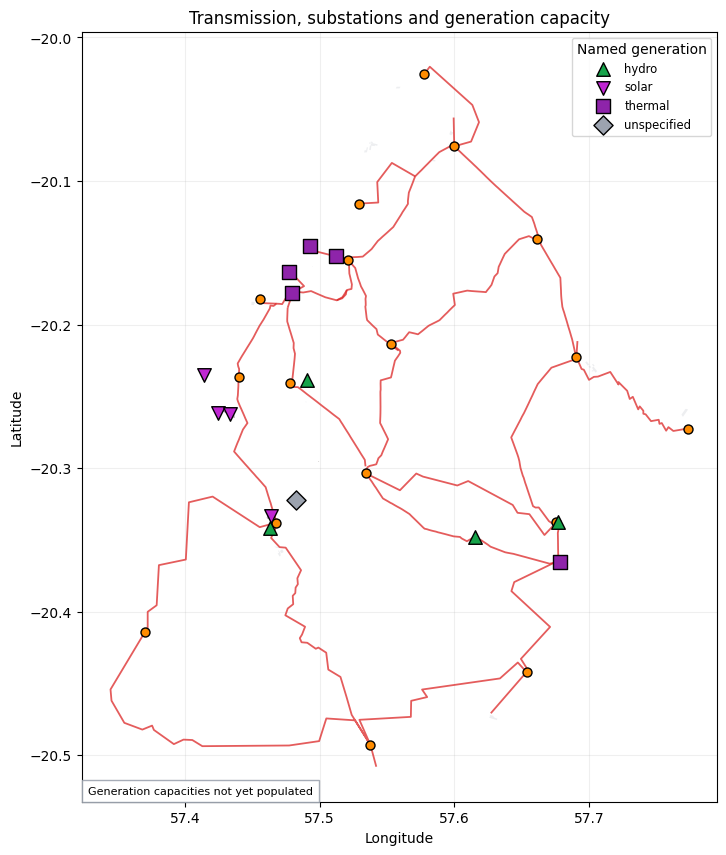

In [4]:
category_colors = {
    "thermal": "#8e24aa",
    "hydro": "#16a34a",
    "solar": "#c026d3",
    "wind": "#2563eb",
    "substation": "#f97316",
    "unspecified": "#9ca3af",
}
category_markers = {"thermal": "s", "hydro": "^", "solar": "v", "wind": "x", "unspecified": "D"}

fig, ax = plt.subplots(figsize=(10, 10))
routes.plot(ax=ax, color="#dc2626", linewidth=1.3, alpha=0.75, zorder=2)
for category, group in generation_areas.groupby("category"):
    alpha = 0.18 if category == "unspecified" else 0.4
    group.plot(
        ax=ax,
        color=category_colors.get(category, "#777777"),
        edgecolor="black" if category != "unspecified" else "none",
        linewidth=0.3,
        alpha=alpha,
        zorder=4,
    )
snapped_substations.plot(ax=ax, color="#ff8c00", edgecolor="black", markersize=42, zorder=6)
for category, group in generator_map_data.groupby("asset_type"):
    ax.scatter(
        group["lon"],
        group["lat"],
        c=category_colors.get(category, "#777777"),
        marker=category_markers.get(category, "D"),
        s=95,
        edgecolors="black" if category != "wind" else None,
        linewidths=1,
        label=category,
        zorder=8,
    )
capacity_rows = generator_map_data.dropna(subset=["capacity_mw"])
for _, row in capacity_rows.iterrows():
    ax.annotate(
        f"{row['capacity_mw']:g} MW_e",
        (row["lon"], row["lat"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=6.5,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 1},
        zorder=10,
    )
if capacity_rows.empty:
    ax.text(
        0.01,
        0.01,
        "Generation capacities not yet populated",
        transform=ax.transAxes,
        fontsize=8,
        bbox={"facecolor": "white", "edgecolor": "#9ca3af", "alpha": 0.9},
    )
ax.set_title("Transmission, substations and generation capacity")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.2)
ax.legend(title="Named generation", fontsize="small")
plt.show()

## Demand information in the workbook

The workbook provides observed monthly system peaks and annual electricity use by customer group. It does not provide the hour-by-hour demand at each substation that the interruption model ultimately needs.

In [5]:
display(monthly_peak.tail(8).style.format("{:.1f}"))
display(
    annual_demand.pivot(index="year", columns="category", values="demand_gwh")
    .tail(8)
    .style.format("{:.1f}")
)

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
year,,,,,,,,,,,,
2018,462.5,468.2,458.2,451.8,430.4,401.9,388.7,394.7,405.2,431.7,442.7,467.1
2019,491.7,489.3,479.9,476.7,436.1,397.9,405.2,402.7,408.0,440.7,463.4,507.2
2020,493.8,491.1,478.0,336.5,349.2,357.7,370.6,362.6,370.4,387.4,406.6,436.3
2021,462.1,451.5,437.0,403.1,402.6,372.0,364.2,366.7,369.0,412.1,436.6,470.8
2022,491.6,472.8,471.1,447.6,432.2,407.6,384.5,390.4,397.9,411.4,445.7,463.0
2023,463.3,476.5,479.9,468.8,448.0,414.2,398.5,400.6,414.1,463.2,469.7,508.4
2024,513.3,525.7,499.4,506.3,468.3,426.9,411.8,413.3,424.2,459.2,484.8,500.2
2025,545.7,567.9,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan


category,(final),Commercial,Domestic,"Industrial, Irrigation, Others"
year,,,,
2016,2558.6,927.8,854.5,776.3
2017,2529.8,921.3,837.7,770.8
2018,2601.1,940.7,872.3,788.1
2019,2684.0,965.1,911.1,807.8
2020,2530.1,883.9,927.5,718.7
2021,2447.8,763.0,952.8,732.0
2022,2611.2,901.5,971.5,738.1
2023,2687.4,980.7,966.9,739.9


## How to interpret and update the data

- Keep source files unchanged under `data/0-incoming`.
- Do not estimate power-station output from polygon area.
- Do not treat unnamed mapped areas as confirmed power stations.
- Record the source and a short explanation for values added manually.
- Clear notebook outputs before committing if they contain private data or large figures.